In [1]:
import pandas as pd

movies = pd.read_csv("clean_movies.csv")

movies.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Profit
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,27998772.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,54353106.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,520375067.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,79953539.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,33846344.0


In [2]:
#kiểm tra dữ liệu thiếu
movies.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
Profit      2232
dtype: int64

In [3]:
#Xem từng tổng số ô bị thiếu
movies.isnull().sum().sum()


np.int64(4705)

In [4]:
#cột thiếu nhiều nhất
movies.isnull().sum().sort_values(ascending=False).head(1)

Profit    2232
dtype: int64

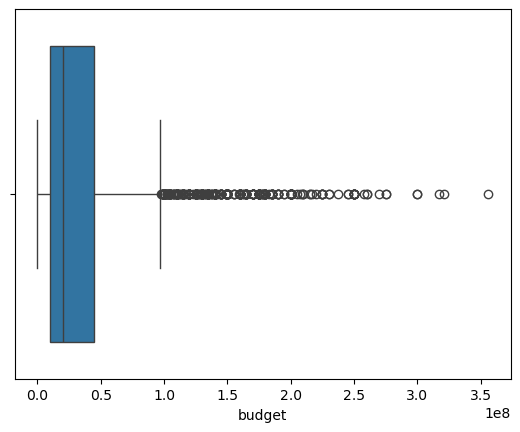

In [5]:
#kiểm tra ngoại lai
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot (x=movies['budget'])
plt.show()

In [6]:
#xem từng khoảng
Q1 = movies["budget"].quantile(0.25)
Q3 = movies["budget"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliners = movies[(movies["budget"] < lower) | (movies["budget"] > upper)]
print (" Số lượng ngoại lai: ", outliners.shape[0])
outliners = outliners.copy()
bins = bins = [0, 50e6, 100e6, 150e6, 200e6, 250e6, 300e6, 350e6, movies["budget"].max()]
labels = [" 0- 50M", " 50M-100M", " 100M - 150M", "150M-200M", "200M-250M", "250M-300M", "300m-350M", ">350M"]
outliners["budget_group"] = pd.cut(outliners["budget"], bins = bins, labels = labels)
print (outliners["budget_group"].value_counts().sort_index())

 Số lượng ngoại lai:  445
budget_group
 0- 50M           0
 50M-100M        63
 100M - 150M    227
150M-200M       116
200M-250M        28
250M-300M         8
300m-350M         2
>350M             1
Name: count, dtype: int64


In [7]:
movies = movies.dropna(subset=["budget", "gross"])
movies["Profit"] = movies["gross"] - movies["budget"]
print ("Missing Profit: ", movies["Profit"].isnull().sum())
movies[["budget", "gross", "Profit"]].head()

Missing Profit:  0


,budget,gross,Profit
0,19000000.0,46998772.0,27998772.0
1,4500000.0,58853106.0,54353106.0
2,18000000.0,538375067.0,520375067.0
3,3500000.0,83453539.0,79953539.0
4,6000000.0,39846344.0,33846344.0


In [8]:
movies.isnull().sum().sort_values(ascending=False)

rating      12
company      2
country      1
runtime      1
name         0
genre        0
year         0
released     0
score        0
votes        0
director     0
writer       0
star         0
budget       0
gross        0
Profit       0
dtype: int64

In [9]:
# Điền rating bằng mode
movies["rating"] = movies["rating"].fillna(movies["rating"].mode()[0])

# Điền company và country bằng Unknown
movies["company"] = movies["company"].fillna("Unknown")
movies["country"] = movies["country"].fillna("Unknown")

# Điền runtime bằng median
movies["runtime"] = movies["runtime"].fillna(movies["runtime"].median())

print("Missing còn lại:", movies.isnull().sum().sum())

Missing còn lại: 0


In [10]:
#xuất file đã làm sạch
movies.to_csv("movies_cleaned.csv", index=False)
import os
os.getcwd()

'c:\\Users\\user\\Documents\\HK2-N2\\LT PYTHON'

In [11]:
#kiểm tra cột genre xem mỗi dòng có bao nhiêu thể loại
movies["genre"].head()

0        Drama
1    Adventure
2       Action
3       Comedy
4       Comedy
Name: genre, dtype: object

In [12]:
#mã hóa biến phân loại
movies_encoded = pd.get_dummies(movies, columns=["genre"])
movies_encoded.head()

,name,rating,year,released,score,votes,director,writer,star,country,...,genre_Crime,genre_Drama,genre_Family,genre_Fantasy,genre_Horror,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_Western
0,The Shining,R,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,...,False,True,False,False,False,False,False,False,False,False
1,The Blue Lagoon,R,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,...,False,False,False,False,False,False,False,False,False,False
2,Star Wars: Episode V - The Empire Strikes Back,PG,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,...,False,False,False,False,False,False,False,False,False,False
3,Airplane!,PG,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,...,False,False,False,False,False,False,False,False,False,False
4,Caddyshack,R,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,...,False,False,False,False,False,False,False,False,False,False


In [13]:
#lưu file đã mã hóa
movies_encoded.to_csv("movies_final.csv", index=False)

In [14]:
movies_encoded[["gross","budget","Profit","score"]].mean()

gross     1.030045e+08
budget    3.593864e+07
Profit    6.706582e+07
score     6.392642e+00
dtype: float64

gross     1.03e+08  → ≈ 103 triệu USD

budget    3.59e+07  → ≈ 35.9 triệu USD

Profit    6.70e+07  → ≈ 67 triệu USD

score     6.39

Doanh thu trung bình (gross) ≈ 103 triệu USD

Ngân sách trung bình (budget) ≈ 36 triệu USD

Lợi nhuận trung bình (Profit) ≈ 67 triệu USD

Điểm đánh giá trung bình (score) ≈ 6.39/10

In [15]:
#tính median
movies_encoded[["gross","budget","Profit","score"]].median()

gross     36711988.0
budget    21000000.0
Profit    13766118.0
score            6.5
dtype: float64

Gross ≈ 36.7 triệu

Budget ≈ 21 triệu

Profit ≈ 13.7 triệu

Score ≈ 6.5

In [16]:
#lập bảng thống kê mô tả đầy đủ
movies_encoded[["gross","budget","Profit","score"]].describe()

,gross,budget,Profit,score
count,5.436000e+03,5.436000e+03,5.436000e+03,5436.000000
mean,1.030045e+08,3.593864e+07,6.706582e+07,6.392642
std,1.871051e+08,4.154770e+07,1.588181e+08,0.963200
min,3.090000e+02,6.000000e+03,-1.580311e+08,1.900000
25%,1.067412e+07,1.000000e+07,-3.177509e+06,5.800000
50%,3.671199e+07,2.100000e+07,1.376612e+07,6.500000
75%,1.119478e+08,4.500000e+07,7.017584e+07,7.100000
max,2.847246e+09,3.560000e+08,2.610246e+09,9.300000


In [17]:
numeric_cols = ["gross", "budget", "Profit", "score"]

for col in numeric_cols:
    Q1 = movies_encoded[col].quantile(0.25)
    Q3 = movies_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = movies_encoded[(movies_encoded[col] < lower) | 
                              (movies_encoded[col] > upper)]
    
    print(f"{col} - Số lượng outlier:", len(outliers))

gross - Số lượng outlier: 551
budget - Số lượng outlier: 445
Profit - Số lượng outlier: 591
score - Số lượng outlier: 86


In [18]:
#đếm số phim theo Thể Loại
genre_cols = [col for col in movies_encoded.columns if "genre_" in col]
movies_encoded[genre_cols].sum().sort_values(ascending=False)

genre_Comedy       1496
genre_Action       1417
genre_Drama         869
genre_Crime         400
genre_Adventure     327
genre_Biography     312
genre_Animation     278
genre_Horror        254
genre_Fantasy        42
genre_Mystery        17
genre_Thriller        7
genre_Sci-Fi          6
genre_Romance         5
genre_Family          4
genre_Western         2
dtype: int64

In [19]:
#đếm phim theo Rating
movies_encoded["rating"].value_counts().sort_index()

rating
APPROVED        1
G             111
NC-17          12
NOT RATED      44
PG            909
PG-13        1730
R            2609
TV-MA           2
UNRATED        17
X               1
Name: count, dtype: int64

In [20]:
#đếm phim theo năm
movies_encoded["year"].value_counts().sort_index()

year
1980     40
1981     63
1982     71
1983     83
1984     90
1985     95
1986     99
1987    104
1988    130
1989    116
1990    111
1991    114
1992    131
1993    143
1994    128
1995    138
1996    144
1997    150
1998    148
1999    163
2000    163
2001    166
2002    173
2003    159
2004    158
2005    170
2006    163
2007    157
2008    171
2009    171
2010    164
2011    160
2012    163
2013    161
2014    163
2015    156
2016    159
2017    133
2018    143
2019    114
2020      8
Name: count, dtype: int64

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv("movies_final.csv")

# Lấy các cột thể loại
genre_cols = [col for col in movies.columns if "genre_" in col]

# Tính doanh thu trung bình theo từng thể loại
avg_gross_by_genre = {}

for col in genre_cols:
    avg_gross_by_genre[col] = movies[movies[col] == 1]["gross"].mean()

# Chuyển thành Series và sắp xếp
avg_gross_by_genre = pd.Series(avg_gross_by_genre).sort_values(ascending=False)

avg_gross_by_genre.head(10)

genre_Family       5.185831e+08
genre_Animation    2.801246e+08
genre_Action       1.678130e+08
genre_Adventure    1.332682e+08
genre_Mystery      1.178877e+08
genre_Biography    6.120711e+07
genre_Drama        6.023144e+07
genre_Comedy       5.916766e+07
genre_Horror       5.614965e+07
genre_Crime        5.008228e+07
dtype: float64

Top doanh thu trung bình:

Family → 518 triệu 

Animation → 280 triệu

Action → 167 triệu

Adventure → 133 triệu

Mystery → 117 triệu

Biography → 61 triệu

Drama → 60 triệu

Comedy → 59 triệu

Horror → 56 triệu

Crime → 50 triệu

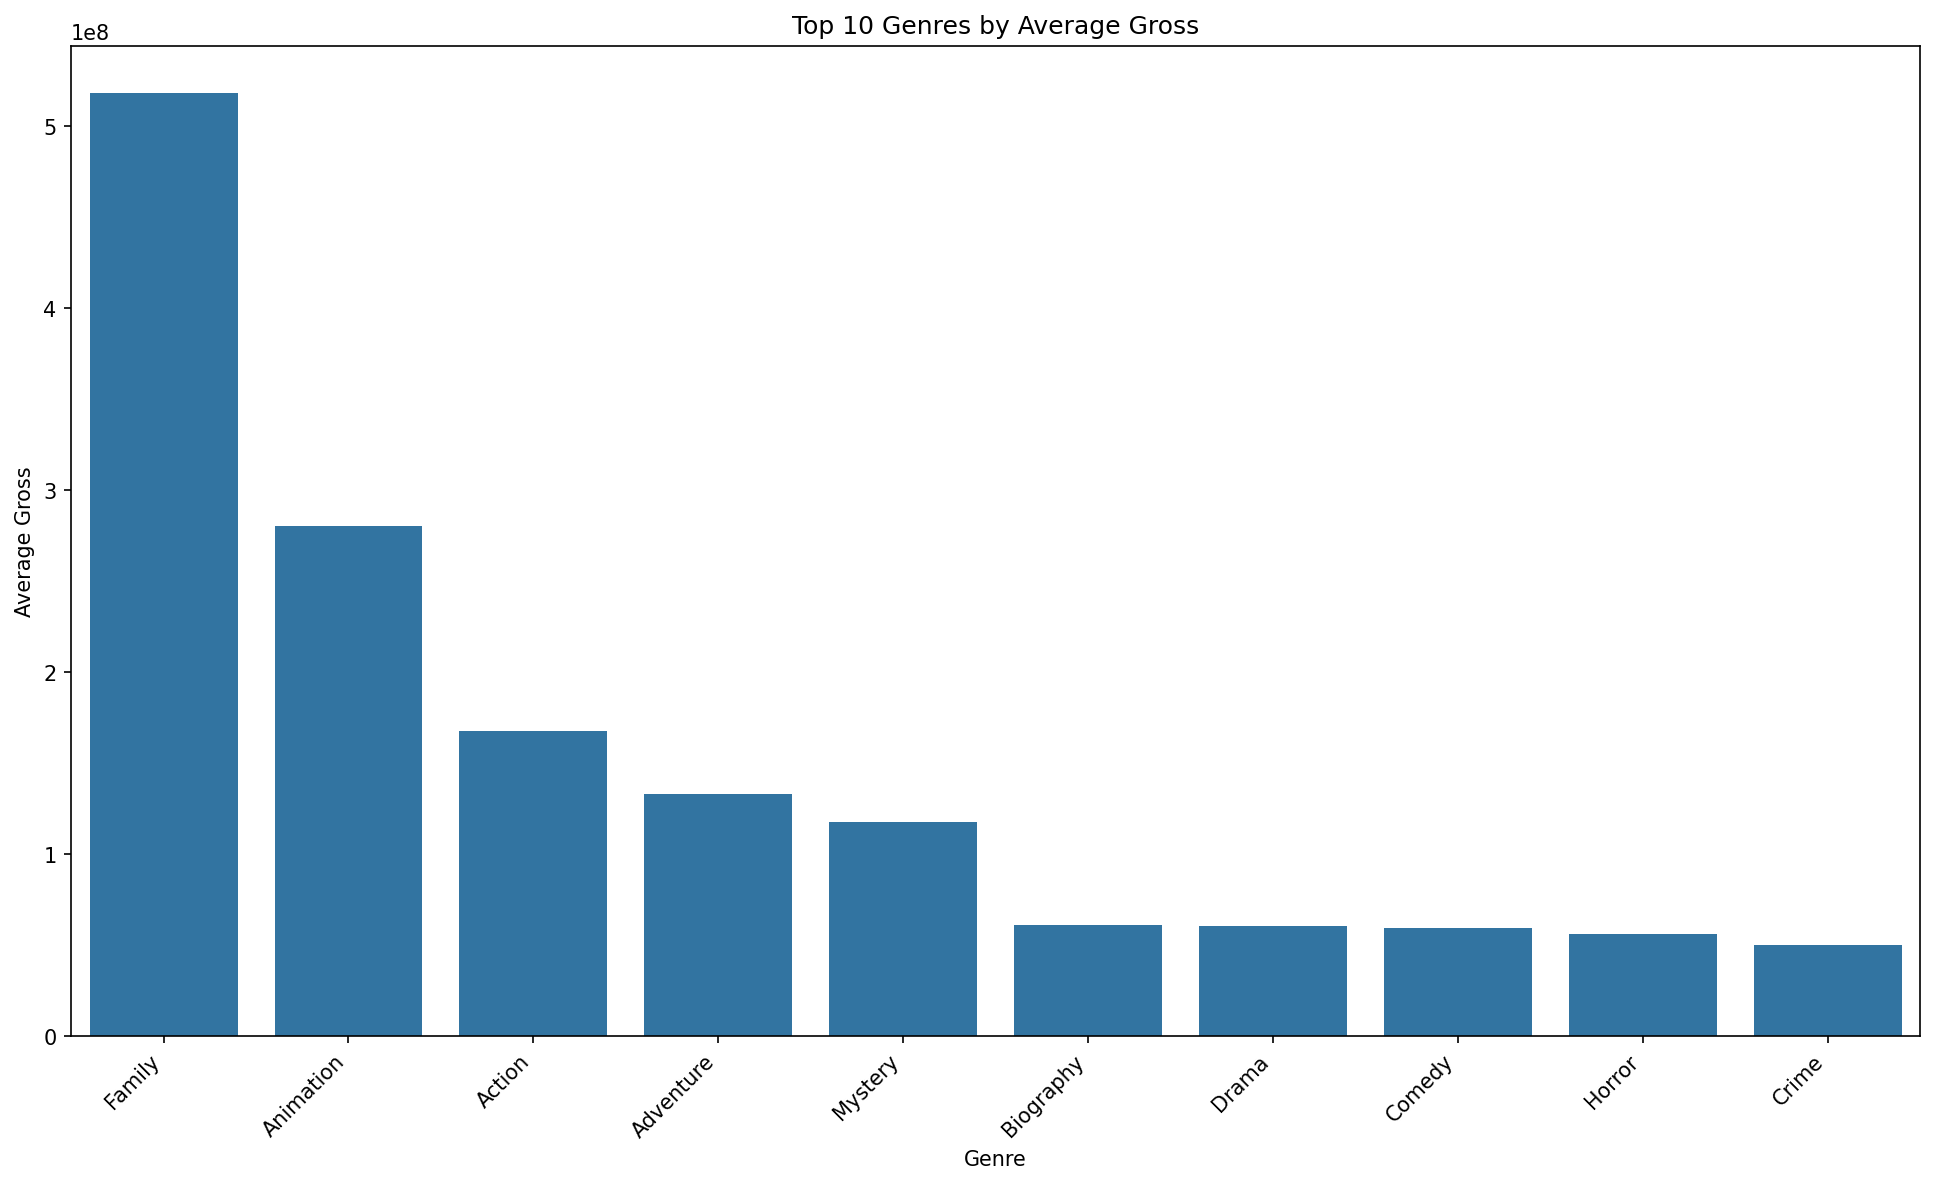

In [22]:
#vẽ barplot doanh thu theo thể loại
top10 = avg_gross_by_genre.head(10)
# bỏ tiền tố genre_
top10.index = top10.index.str.replace("genre_", "")
plt.figure(figsize=(13,8), dpi=150)
sns.barplot(x=top10.index, y=top10.values)
plt.title("Top 10 Genres by Average Gross")
plt.xlabel("Genre")
plt.ylabel("Average Gross")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Nhận xét:
- Các thể loại như Family, Animation, Action, Adventure có doanh thu trung bình cao nhất.
- Điều này cho thấy các phim hướng đến khán giả đại chúng và thị trường quốc tế thường đoạt doanh thu cao.
- Các thể loại phim như Drama, Comedy có doanh thu thấp hơn vì:
    + Phimm thường ngân sách ít hơn.
    + Ít yếu tố bom tấn, kỹ xảo.

In [23]:
# tính doanh thu trung bình theo đạo diễn
avg_gross_by_director = (
    movies.groupby("director")["gross"]
    .mean()
    .sort_values(ascending=False)
)

avg_gross_by_director.head(10)

director
Anthony Russo    1.368850e+09
Kyle Balda       1.097122e+09
Josh Cooley      1.073395e+09
Chris Buck       1.059909e+09
Joss Whedon      9.873567e+08
Lee Unkrich      9.373943e+08
James Cameron    8.925841e+08
George Lucas     8.497511e+08
David Yates      8.407581e+08
J.J. Abrams      7.765626e+08
Name: gross, dtype: float64

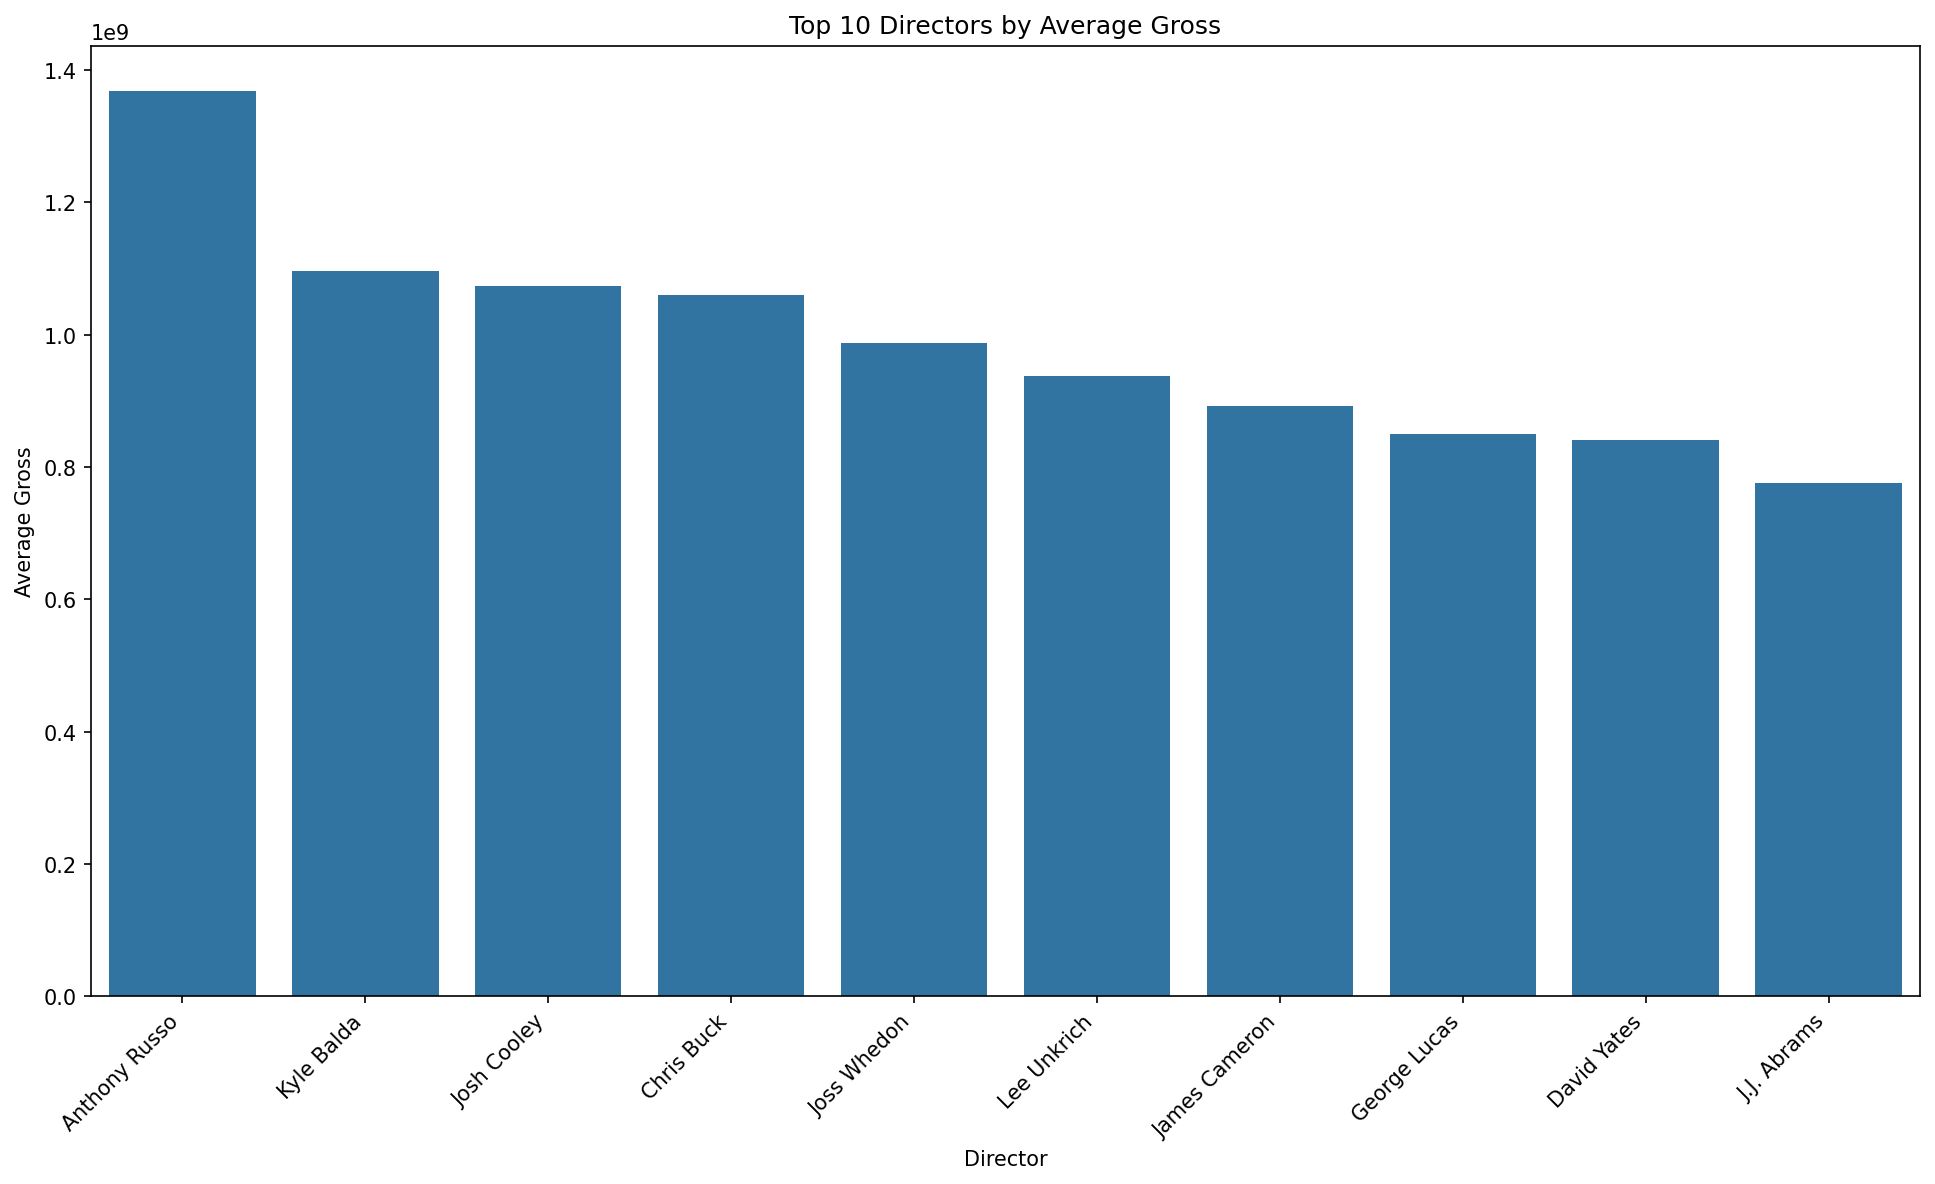

In [24]:
#vẽ barplot theo doanh thu đạo diễn
top10_director = avg_gross_by_director.head(10)
plt.figure(figsize=(13,8), dpi=150)
sns.barplot(x=top10_director.index, y=top10_director.values)
plt.title("Top 10 Directors by Average Gross")
plt.xlabel("Director")
plt.ylabel("Average Gross")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Nhận xét:
- Những đạo diễn đứng đầu đều gắn liền với các phim bom tấn toàn cầu.
- Doanh thu trung bình cao vì họ là đạo diễn các phim thuộc vũ trụ điện ảnh lớn.
- Một số đạo diễn có doanh thu trung bình cao do:
    + Số lương phim ít những chất lượng phim đều là siêu bom tấn.

Nhận xét - so sánh 2 biểu đồ:
- Thể loại ảnh hướng đến xu huongs khán giả.
- Đạo diễn ảnh hưởng đến quy mô và thành công thương mại.
=> Cả hai yếu tố đều có vai trò quan trọng trong doanh thu phim

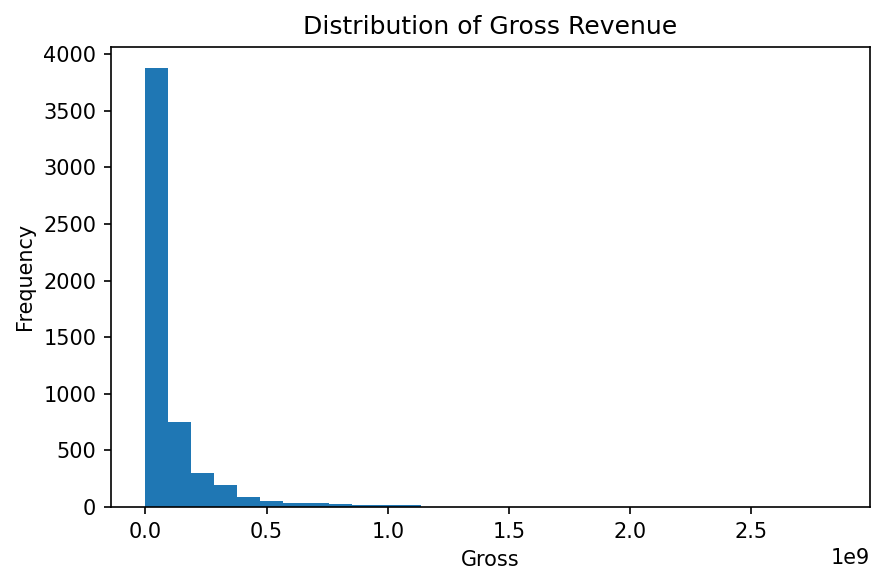

In [25]:
#vẽ histogram cho gross ( doanh thu)
plt.figure(figsize=(6,4), dpi=150)
plt.hist(movies["gross"], bins=30)
plt.title("Distribution of Gross Revenue")
plt.xlabel("Gross")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Nhận xét:
- Phân bố lệch phải ( right-skewed).
- Phần lớn phim có doanh thu trung bình hoặc thấp.
- Một số ít phim có doanh thu cực cao ( bom tấn).
 
=> Điểu này cho thấy thị trường phim có tính cạnh tranh cao. Chỉ một số ít phim tạo ra doanh thu khủng lồ.

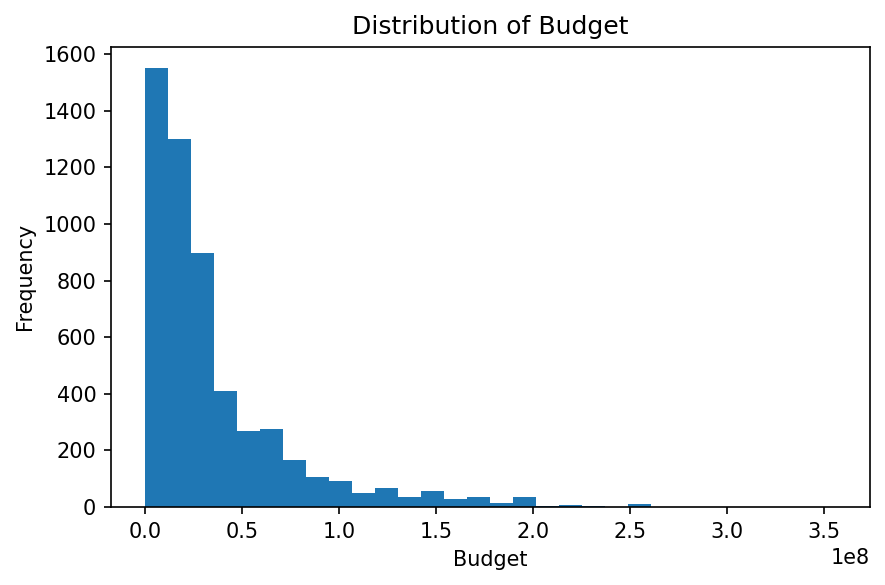

In [26]:
#vẽ histogram cho budget ( ngân sách)
plt.figure(figsize=(6,4), dpi=150)
plt.hist(movies["budget"], bins=30)
plt.title("Distribution of Budget")
plt.xlabel("Budget")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Nhận xét:
- Phân bố lệch phải ( right-skewed).
- Phần lớn phim có ngân sách ở mức thấp đến trung bình.
- Chỉ có một số ít phim có ngân sách cực cao ( bom tấn).

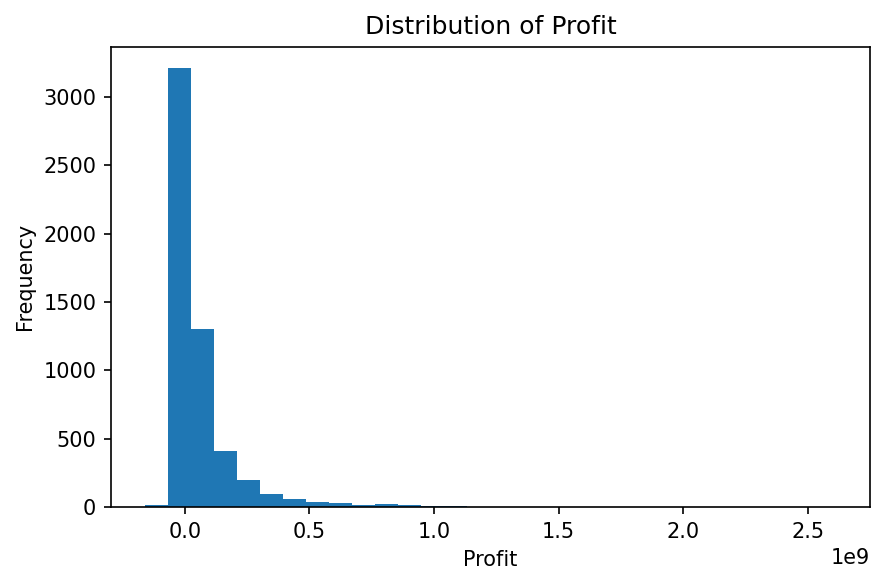

In [27]:
#vẽ histogram cho profit ( lợi nhuận)
plt.figure(figsize=(6,4), dpi=150)
plt.hist(movies["Profit"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Nhận xét:
- Phân bố rộng hơn so với budget.
- Có cả giá trị âm ( phim lỗ).
- Vân lệch phải vì có một số phim lợi nhuận cực kì cao.

=> Lợi nhuận phân bố rộng và có nhiều phim bị lỗ, cho thấy đầu tư lớn không đảm bảo thành công. Tuy nhiên, một số ít phim đạt lợi nhuận vượt trội, kéo phân bố lệch về phía giá trị cao.


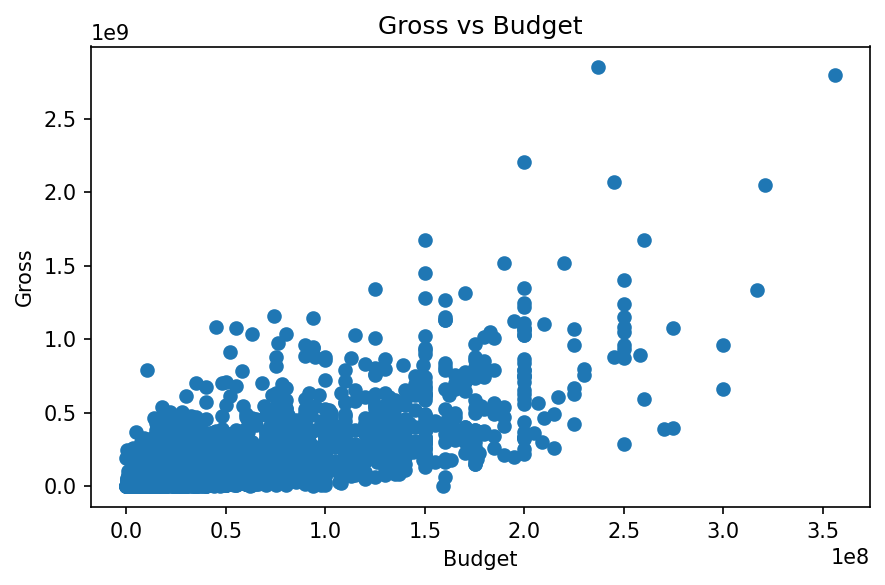

In [28]:
#vẽ scatter plot giữa doanh thu và budget
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(movies["budget"], movies["gross"])
plt.title("Gross vs Budget")
plt.xlabel("Budget")
plt.ylabel("Gross")
plt.tight_layout()
plt.show()

Nhận xét:
- Thường có tương quan dương (hướng) rõ rệt (Khi một biến tăng thì biến kia cũng có xu hướng tăng theo).
- Budget tăng -> Doanh thu có xu hướng tăng.
- Vẫn còn nhiều điểm phân tán -> Không phải đầu tư lớn là chắc chắn thành công.

=> Mối quan hệ mạnh nhất




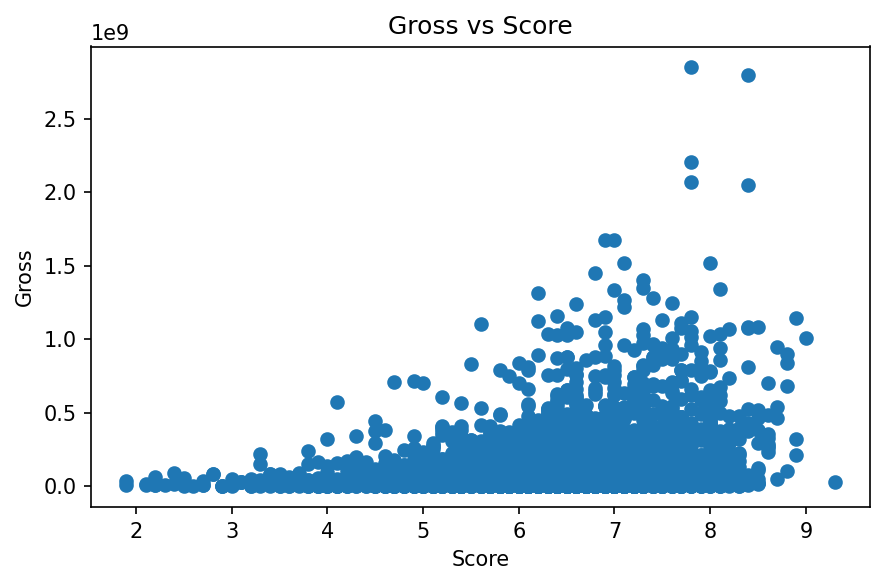

In [29]:
#vẽ scatter plot giữa doanh thu và score
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(movies["score"], movies["gross"])
plt.title("Gross vs Score")
plt.xlabel("Score")
plt.ylabel("Gross")
plt.tight_layout()
plt.show()

Nhận xét:
- Tương quan yếu hoặc rất yếu. ( mức độ)
- Phim điểm cao chưa chắc doanh thu cao.
- Một vài phim điểm trung bình nhưng vẫn có doanh thu lớn.

=> Chất lượng chuyên môn không quyết định hoàn toàn doanh thu.

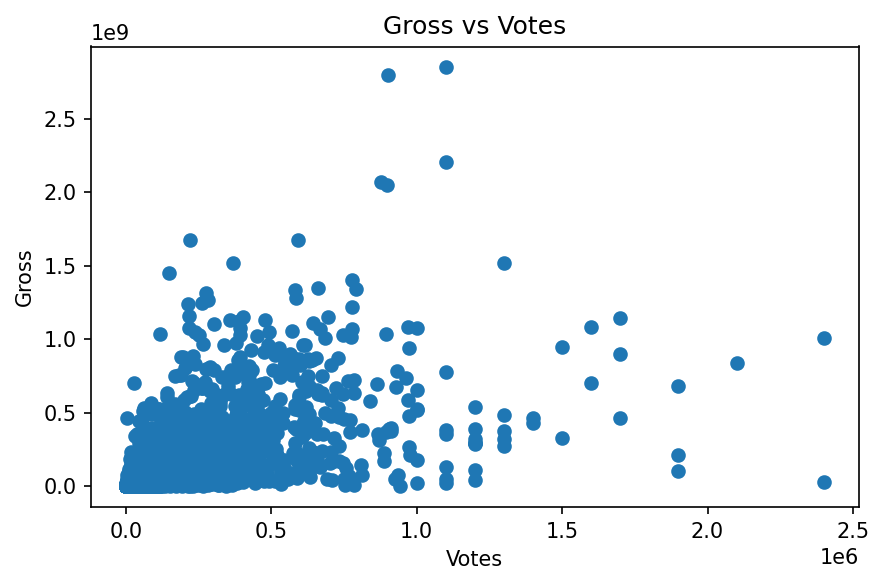

In [30]:
#vẽ scatter plot giữa doanh thu với votes
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(movies["votes"], movies["gross"])
plt.title("Gross vs Votes")
plt.xlabel("Votes")
plt.ylabel("Gross")
plt.tight_layout()
plt.show()


Nhận xét:
- Có tương quan dương rõ rệt.
- Phim nhiều lượt bình chọn thường có doanh thu cao ( vì phim nổi tiếng -> nhiều người xem -> nhiều votes).

=> Votes phản ánh độ phổ biến tốt hơn Score.

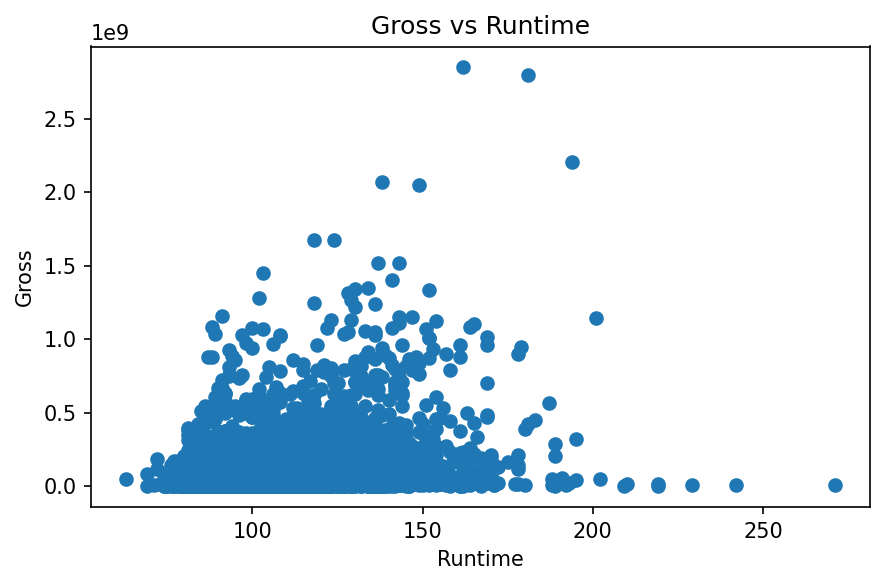

In [31]:
#vẽ scater plot giữa doanh thu với runtime (thời lượng):
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(movies["runtime"], movies["gross"])
plt.title("Gross vs Runtime")
plt.xlabel("Runtime")
plt.ylabel("Gross")
plt.tight_layout()
plt.show()

Nhận xét:
- Hầu như không có tương quan rõ ràng.
- Thời lượng phim không quyết định doanh thu 
- Phim dài chưa chắc kiếm nhiều tiền.

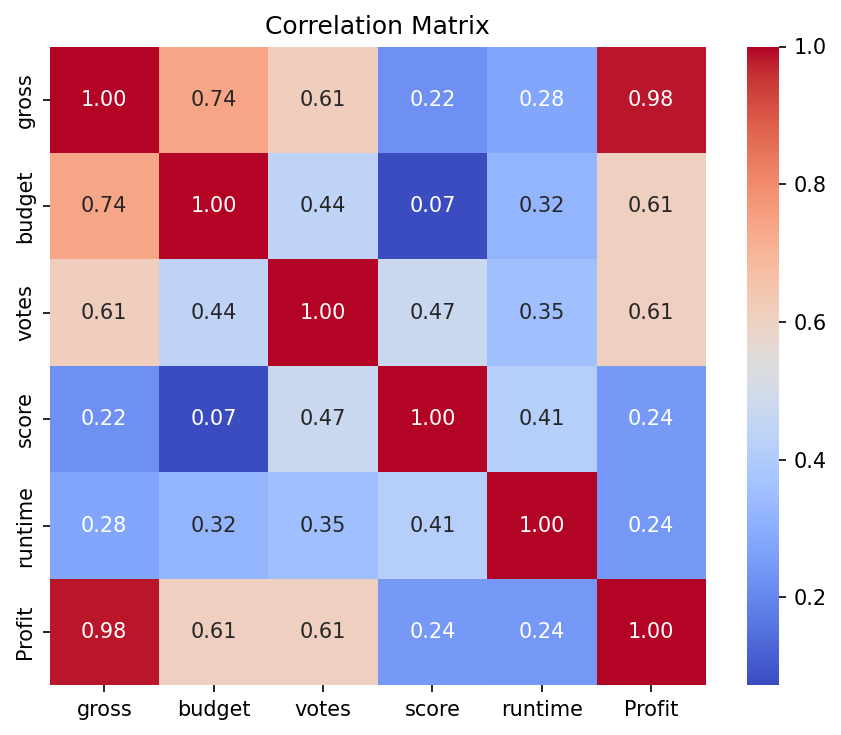

In [32]:
#vẽ heat map giữa doanh thu với các biến ( chi tiết)
plt.figure(figsize=(6,5), dpi=150)
corr_matrix = movies[["gross","budget","votes","score","runtime","Profit"]].corr()
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

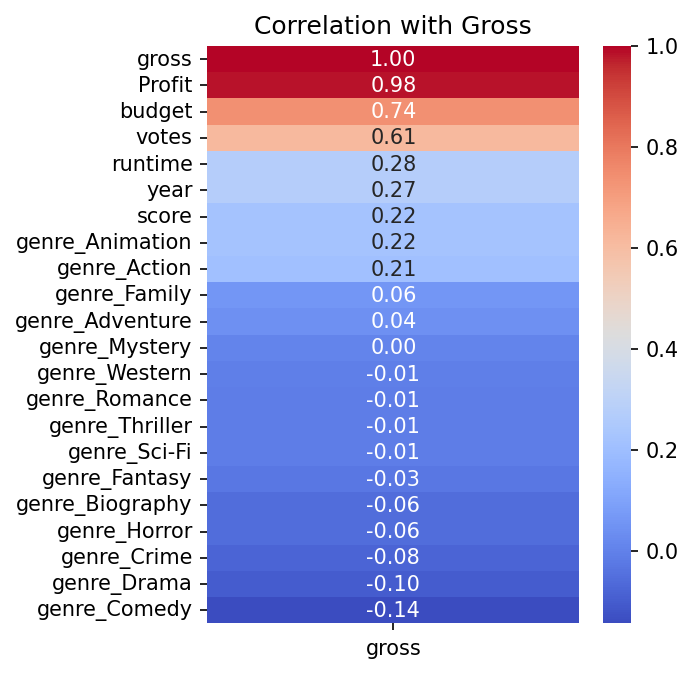

In [33]:
corr_gross = movies.corr(numeric_only=True)[['gross']].sort_values(
by='gross', ascending=False)
plt.figure(figsize=(4,5), dpi=150)
sns.heatmap(corr_gross, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Gross")
plt.show()

Nhận xét:
- Gross với Profit (0.98 -> tương quan rất mạnh)

    Gần như hoàn hảo vì Profit = Gross - Budget

    => Gross tăng -> Profit tăng gần như trực tiếp.

- Gross với Budget (0.74 -> tương quan mạnh)

    Phim có đầu tư thường có doanh thu cao hơn.

    Budget là yếu tố quan trọng ảnh hưởng rõ đến doanh thu.

- Gross với Votes (0.61 -> tương quan khá mạnh)

    Phim nhiều lượt đánh giá thường có doanh thu cao hơn.

- Gross với Runtime ( 0.28 -> tương quan yếu)

    Thời lượng phim ảnh hưởng không đáng kể đến doanh thu.

- Gross với Score ( 0.22 -> tương quan rất yếu)

    Điểm đánh giá cao không đảm bảo doanh thu cao.

    Một số phim có chất lượng nghệ thuật tốt nhưng không đạt thành công thương mại.

- Gross với Genre:

    +) Các hệ số tương quan giữa từng thể loại và doanh thu đều rất nhỏ (gần 0).

        Action, Animation: xu hướng dương nhẹ

        Comedy, Drama: xu hướng âm nhẹ  

=> Thể loại ảnh hưởng không đáng kể đến doanh thu.

KẾT LUẬN:

Doanh thu phim chịu ảnh hưởng chủ yếu bởi mức đầu tư (Budget) và mức độ phổ biến (Votes).
Các yếu tố như Runtime, Score và Genre không có tác động mạnh đến doanh thu.



Dữ liệu có cần log-transform không?

Có thể cân nhắc. Vì: 

    - Gross, Budget và Profit đều lệch phải mạnh.

    - Có giá trị rất lớn làm kéo trung bình lên cao.

    - Log-transform giúp:

        Giảm ảnh hưởng của outlier

        Phân bố cân đối hơn

        Phù hợp hơn cho mô hình hồi quy

=> Nếu xây dựng mô hình dự đoán → nên dùng log(gross).


Nên chọn biến nào cho mô hình?

Dựa trên mức tương quan:

Nên chọn:

- Budget (quan trọng nhất)

- Votes (khá quan trọng)

Có thể xem xét:

- Score (ảnh hưởng yếu nhưng có thể bổ sung)
